# Computing Scenarios based on Yearsets

> Based on initial exploration in 0513_distribution-exploration

## Imports

In [2]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [4]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict.keys()

dict_keys(['TC', 'TP', 'HL', 'FL'])

In [5]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

# For Merged Hazard
hazard_types.append("MG")

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,impf_FL,impf_MG,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


---

# Creating Combined Hazard Object

In [6]:
from src.data_exposure import get_exposure
from climada.entity import Exposures
import climada.util.lines_polys_handler as u_lp
from copy import deepcopy

exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=10000,      # TODO: Go back down to KM for Flood and Hail
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

## Poly -> Eigen Raster Exposure
exposure_pnt_eigen_gdf = deepcopy(exposure_pnt.gdf)
exposure_pnt_eigen_gdf["value"] = 1
exposure_pnt_eigen = Exposures(exposure_pnt_eigen_gdf)

2026-05-20 14:51:44,368 - climada.util.lines_polys_handler - WARNING - Polygon smaller than resolution. Setting a representative point.
2026-05-20 14:51:44,409 - climada.util.lines_polys_handler - WARNING - Polygon smaller than resolution. Setting a representative point.


In [10]:
from climada.engine import ImpactCalc

imp_mat_list= []
freq_list = []

for key, value in haz_dict.items():
    print(f"Computing Impact for {key}")
    
    hazard = value["hazard"]
    impf_set = value["impf_set"]
    
    impact = ImpactCalc(
        exposure_pnt_eigen,
        impfset=impf_set,
        hazard=hazard
    ).impact(save_mat=True)
    
    imp_mat_list.append(
        impact.imp_mat
    )
    
    freq_list.append(
        impact.frequency
    )
    
    haz_dict[key]["impact"] = impact

Computing Impact for TC
Computing Impact for TP
Computing Impact for HL
2026-05-20 14:53:57,738 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 5411 coordinates.
2026-05-20 14:53:57,742 - climada.engine.impact_calc - WARNING - No exposures with value >0 in the vicinity of the hazard.
Computing Impact for FL
2026-05-20 15:00:22,107 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.004492 degree for 135 coordinates.


In [11]:
from scipy.sparse import vstack
import numpy as np

imp_mat_stacked = vstack(imp_mat_list)

freq_stacked = np.concatenate(freq_list)

In [12]:
from climada.hazard.centroids import Centroids

coords = impact.coord_exp

centroids = Centroids(
    lat=coords[:, 0],
    lon=coords[:, 1]
)

In [13]:
fraction_mat = imp_mat_stacked.copy()
fraction_mat.data[:] = 1.0

In [14]:
from climada.hazard import Hazard

n_events, n_points = imp_mat_stacked.shape

hazard_combined = Hazard(haz_type="MG")

hazard_combined.centroids = centroids

hazard_combined.intensity = imp_mat_stacked
hazard_combined.frequency = freq_stacked
hazard_combined.fraction = fraction_mat

## Adding Infos
hazard_combined.event_id = np.arange(1, n_events + 1)
hazard_combined.event_name = np.array([f"event_{i}" for i in hazard_combined.event_id])
hazard_combined.date = np.arange(n_events).astype("datetime64[D]")


# --- Metadata ---
hazard_combined.units = "rel"
hazard_combined.tag = {
    "description": "Merged Events into Relative Impacts"
}

hazard_combined

## Combined Hazard -> Impact

> via Eigenexposure and Eigenvulnerability

In [15]:
## Defining Eigen Impact Function

from climada.entity import ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet

impf_eigen = ImpactFunc(
    id=1,
    name = "Total Precipitation Impact Function (ChatGPT)",
    intensity_unit="mm",
    haz_type=hazard_combined.haz_type,
    intensity=np.array([0, 1]),
    mdd=np.array([0, 1]),
    paa = np.ones(2)
)

impf_eigen_set = ImpactFuncSet([impf_eigen])

In [16]:
impact_combined = ImpactCalc(
        exposures=exposure_pnt_eigen,
        impfset=impf_eigen_set,
        hazard=hazard_combined
    ).impact(save_mat=True)

impact_combined

---

# Building and Sampling from Yearsets

Turning Impact into Yearsets allows us to turn the varying types of Hazards into Yearly Impacts at each point in space

In [17]:
## Sampling a Yearset -> Computing Yearly Impacts

import numpy as np
import climada.util.yearsets as yearsets
from climada.engine import Impact

sampled_years = list(range(1900, 2000))

# direct computation
yimp, sampling_vect = yearsets.impact_yearset(
    impact_combined, sampled_years, correction_fac=False,
)

2026-05-20 15:00:35,762 - climada.util.yearsets - WARNING - The frequencies of the different events are not equal. This can lead to distorted sampling if the frequencies vary significantly. To avoid this, please set `with_replacement=True` to sample with replacement instead.


In [18]:
## Manually creating imp_mat for Yearset

import scipy.sparse as sp

sparse_matrix = impact_combined.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sp.csr_matrix(1.-(1.-sparse_matrix[indices, :].toarray()).prod(axis=0))
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yimp.imp_mat = summed_matrix

yimp.coord_exp = impact_combined.coord_exp
yimp.at_event, yimp.eai_exp, yimp.aai_agg = (
    ImpactCalc.risk_metrics(yimp.imp_mat, yimp.frequency)
)

In [19]:
## !!! Not actually necessary !!!

## Computing Local Return Periods for Tresholds
from climada.util.plot import plot_from_gdf

threshold_values = [.20, .50]
gdf_rp, title, cols = yimp.local_return_period(threshold_values, method="extrapolate_constant")

array([<GeoAxes: title={'center': 'Impact: 0.2 USD'}>,
       <GeoAxes: title={'center': 'Impact: 0.5 USD'}>], dtype=object)

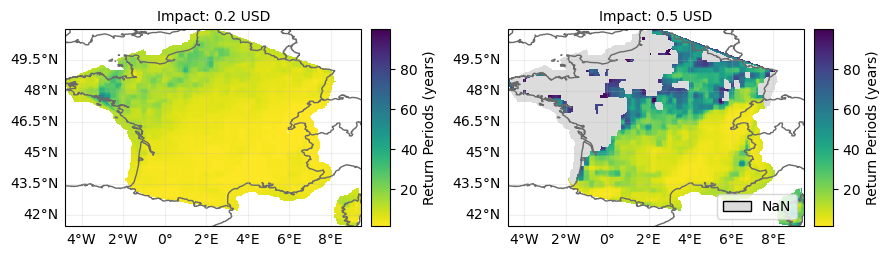

In [20]:
plot_from_gdf(gdf_rp, title, cols)

---

# Using Yearsets to Infer Payment Distribution